# CNN-Transformer Hybrid Model — Multi-Dataset Comparison

This notebook trains a CNN-Transformer hybrid architecture using
Leave-One-Subject-Out (LOSO) cross-validation, and is designed to be
re-run on three different datasets (UCI HAR, PAMAP2, RealWorld) by only
changing the data-loading cell.

Architecture:
Input -> CNN -> Feature Maps -> Positional Encoding -> Transformer Encoder
-> Global Average Pooling -> 64-D Vector -> Linear Classifier -> Prediction

In [20]:
# Import all libraries needed for data handling, model building, and evaluation
import copy
import time
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Load Dataset

**This is the only cell you will change when switching between datasets.**
Currently set to load PAMAP2. To switch datasets later, comment out this
block and uncomment the UCI HAR or RealWorld block below it.

In [21]:
# ============================================
# DATASET SELECTION — uncomment ONE block only
# ============================================

DATASET = "REALWORLD"   # options: "PAMAP2", "UCI", "REALWORLD"

if DATASET == "PAMAP2":
    X = np.load('/lustre09/project/6081099/reem2005/DATASET/X_windows.npy')
    y = np.load('/lustre09/project/6081099/reem2005/DATASET/y_windows.npy')
    groups = np.load('/lustre09/project/6081099/reem2005/DATASET/groups.npy')

elif DATASET == "UCI":
    from pathlib import Path

    UCI_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/UCI HAR Dataset")
    UCI_SAVE_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/UCI_PROCESSED")
    UCI_SAVE_DIR.mkdir(exist_ok=True)

    uci_npy_exists = (UCI_SAVE_DIR / "X_windows.npy").exists()

    if uci_npy_exists:
        # Fast path: load pre-saved arrays if they already exist
        X = np.load(UCI_SAVE_DIR / "X_windows.npy")
        y = np.load(UCI_SAVE_DIR / "y_windows.npy")
        groups = np.load(UCI_SAVE_DIR / "groups.npy")
    else:
        # First-time load: build arrays from the raw UCI HAR text files
        SIGNAL_NAMES = [
            "body_acc_x", "body_acc_y", "body_acc_z",
            "body_gyro_x", "body_gyro_y", "body_gyro_z",
            "total_acc_x", "total_acc_y", "total_acc_z",
        ]

        def load_signal(split, name):
            path = UCI_DIR / split / "Inertial Signals" / f"{name}_{split}.txt"
            return np.loadtxt(path)

        def build_tensor(split):
            signals = [load_signal(split, name) for name in SIGNAL_NAMES]
            return np.stack(signals, axis=2)

        X_train = build_tensor("train")
        X_test = build_tensor("test")

        y_train = np.loadtxt(UCI_DIR / "train" / "y_train.txt").astype(int) - 1
        y_test = np.loadtxt(UCI_DIR / "test" / "y_test.txt").astype(int) - 1

        subject_train = np.loadtxt(UCI_DIR / "train" / "subject_train.txt").astype(int)
        subject_test = np.loadtxt(UCI_DIR / "test" / "subject_test.txt").astype(int)

        X = np.concatenate([X_train, X_test], axis=0).astype("float32")
        y = np.concatenate([y_train, y_test], axis=0)
        groups = np.concatenate([subject_train, subject_test], axis=0)

        # Save for fast reuse next time
        np.save(UCI_SAVE_DIR / "X_windows.npy", X)
        np.save(UCI_SAVE_DIR / "y_windows.npy", y)
        np.save(UCI_SAVE_DIR / "groups.npy", groups)
        print("UCI arrays built from raw files and saved to:", UCI_SAVE_DIR)

elif DATASET == "REALWORLD":
    from pathlib import Path
    DATA_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/PROCESSED")
    X = np.load(DATA_DIR / "X_windows.npy")
    y = np.load(DATA_DIR / "y_windows.npy")
    groups = np.load(DATA_DIR / "groups.npy")

else:
    raise ValueError(f"Unknown DATASET: {DATASET}")

print("Dataset:", DATASET)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of subjects:", len(np.unique(groups)))
print("Number of classes:", len(np.unique(y)))

Dataset: REALWORLD
X shape: (435295, 100, 9)
y shape: (435295,)
Number of subjects: 15
Number of classes: 8


## Configuration

Hyperparameters for training. `INPUT_WINDOW`, `INPUT_FEATURES`, and
`NUM_CLASSES` are derived automatically from whichever dataset was loaded
in the previous cell — no manual changes needed when switching datasets.

In [22]:
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 7
GRAD_CLIP_NORM = 5.0

INPUT_WINDOW = X.shape[1]
INPUT_FEATURES = X.shape[2]
NUM_CLASSES = len(np.unique(y))
RANDOM_SEED = 42

print(f"Window: {INPUT_WINDOW} | Features: {INPUT_FEATURES} | Classes: {NUM_CLASSES} | Subjects: {len(np.unique(groups))}")

Window: 100 | Features: 9 | Classes: 8 | Subjects: 15


## PyTorch Dataset Class

Wraps the numpy arrays so PyTorch's DataLoader can iterate over them in
batches during training.

In [23]:
class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## Positional Encoding

The Transformer has no built-in sense of sequence order — unlike a CNN
or RNN, it processes all timesteps in parallel. Positional encoding
injects information about each timestep's position by adding a fixed
sinusoidal pattern to the CNN's output before it enters the Transformer.

In [24]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

## CNN-Transformer Hybrid Model

Architecture:
Input -> CNN -> Feature Maps -> Positional Encoding -> Transformer Encoder
-> Global Average Pooling -> 64-D Vector -> Linear Classifier -> Prediction

- **CNN**: extracts local temporal patterns from the raw signal
- **Positional Encoding**: adds timestep order information (see above)
- **Transformer Encoder**: models relationships between all timesteps
  simultaneously via self-attention, capturing long-range dependencies
  that CNN alone cannot
- **Global Average Pooling**: collapses the sequence into a single
  summary vector by averaging across all timesteps
- **Linear Classifier**: maps the final vector to an activity prediction

In [25]:
class CNNTransformerClassifier(nn.Module):
    def __init__(self, input_window, input_features, num_classes,
                 cnn_channels=64, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.3):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(input_features, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.pos_encoding = PositionalEncoding(d_model, max_len=input_window)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (batch, features, window) for Conv1d
        x = self.cnn(x)                 # (batch, d_model, window)
        x = x.permute(0, 2, 1)          # (batch, window, d_model) for Transformer

        x = self.pos_encoding(x)
        x = self.transformer_encoder(x) # (batch, window, d_model)

        x = x.mean(dim=1)               # Global Average Pooling -> (batch, d_model)

        return self.classifier(x)       # (batch, num_classes)

## Training and Evaluation Functions

`train_one_epoch`: runs one full pass over the training data, updating
the model's weights. Gradient clipping is applied to prevent unstable
updates (a known risk with attention-based architectures).

`evaluate`: runs the model in inference mode (no weight updates) and
computes macro F1-score, the main metric used throughout this project.

In [26]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1_macro, all_labels, all_preds

## Leave-One-Subject-Out (LOSO) Runner

For each held-out test subject, an additional subject from the remaining
pool is set aside as an inner validation set (used only for early
stopping / best-epoch selection). The test subject is never seen during
training — no data leakage. This is the same evaluation protocol used
consistently throughout this project.

In [27]:
def run_loso_experiment(epochs=EPOCHS, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    unique_subjects = np.unique(groups)

    fold_f1s, fold_accuracies = [], []
    all_y_true, all_y_pred = [], []

    for fold, test_subject in enumerate(unique_subjects, 1):
        train_subjects_all = unique_subjects[unique_subjects != test_subject]

        rng = np.random.RandomState(RANDOM_SEED + fold)
        val_subject = rng.choice(train_subjects_all)
        train_subjects = train_subjects_all[train_subjects_all != val_subject]

        train_mask = np.isin(groups, train_subjects)
        val_mask = groups == val_subject
        test_mask = groups == test_subject

        X_train, y_train = X[train_mask], y[train_mask]
        X_val, y_val = X[val_mask], y[val_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        train_loader = DataLoader(HARDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(HARDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(HARDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

        model = CNNTransformerClassifier(INPUT_WINDOW, INPUT_FEATURES, NUM_CLASSES).to(device)

        class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
        class_weights = torch.tensor(
            len(y_train) / (NUM_CLASSES * np.maximum(class_counts, 1)), dtype=torch.float32
        ).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

        best_val_f1 = -1
        best_model_state = None
        patience_counter = 0

        for epoch in range(epochs):
            train_one_epoch(model, train_loader, optimizer, criterion, device)
            _, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
            scheduler.step(val_f1)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    break

        model.load_state_dict(best_model_state)
        _, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion, device)
        test_acc = accuracy_score(y_true, y_pred)

        fold_f1s.append(test_f1)
        fold_accuracies.append(test_acc)
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)

        if verbose:
            print(f"Fold {fold:2d} | test_subject={test_subject} | Acc={test_acc:.4f} | F1={test_f1:.4f}")

    return {
        "fold_f1s": fold_f1s,
        "fold_accuracies": fold_accuracies,
        "mean_f1": np.mean(fold_f1s),
        "std_f1": np.std(fold_f1s),
        "mean_accuracy": np.mean(fold_accuracies),
        "std_accuracy": np.std(fold_accuracies),
        "y_true": all_y_true,
        "y_pred": all_y_pred,
    }

## Run the Experiment

Trains and evaluates the CNN-Transformer model across all LOSO folds for
whichever dataset was loaded in Cell 4 (`DATASET` variable).

In [28]:
t0 = time.time()
results = run_loso_experiment(epochs=EPOCHS, verbose=True)
elapsed = time.time() - t0

print(f"\n{'='*60}")
print(f"CNN-Transformer Results — {DATASET} ({len(np.unique(groups))} folds)")
print(f"{'='*60}")
print(f"Mean Accuracy: {results['mean_accuracy']:.4f} ± {results['std_accuracy']:.4f}")
print(f"Mean Macro F1: {results['mean_f1']:.4f} ± {results['std_f1']:.4f}")
print(f"Time: {elapsed/60:.1f} min")

Fold  1 | test_subject=0 | Acc=0.6881 | F1=0.6991
Fold  2 | test_subject=1 | Acc=0.7059 | F1=0.7427
Fold  3 | test_subject=2 | Acc=0.7839 | F1=0.7951
Fold  4 | test_subject=3 | Acc=0.6747 | F1=0.6865
Fold  5 | test_subject=4 | Acc=0.7330 | F1=0.7338
Fold  6 | test_subject=5 | Acc=0.7376 | F1=0.7305
Fold  7 | test_subject=6 | Acc=0.7079 | F1=0.7197
Fold  8 | test_subject=7 | Acc=0.6912 | F1=0.6834
Fold  9 | test_subject=8 | Acc=0.6162 | F1=0.6195
Fold 10 | test_subject=9 | Acc=0.5922 | F1=0.6262
Fold 11 | test_subject=10 | Acc=0.6486 | F1=0.6710
Fold 12 | test_subject=11 | Acc=0.7271 | F1=0.7443
Fold 13 | test_subject=12 | Acc=0.6817 | F1=0.6969
Fold 15 | test_subject=14 | Acc=0.7288 | F1=0.7514

CNN-Transformer Results — REALWORLD (15 folds)
Mean Accuracy: 0.6850 ± 0.0580
Mean Macro F1: 0.6980 ± 0.0566
Time: 66.1 min


## Classification Report and Confusion Matrix

CNN-Transformer — REALWORLD Classification Report
              precision    recall  f1-score   support

           0     0.7653    0.7808    0.7730     48295
           1     0.7840    0.6987    0.7389     59670
           2     0.6955    0.8830    0.7781      9259
           3     0.6135    0.7513    0.6754     62692
           4     0.9288    0.7624    0.8374     68882
           5     0.4324    0.4121    0.4220     62525
           6     0.5654    0.5860    0.5755     61542
           7     0.7459    0.7693    0.7574     62430

    accuracy                         0.6824    435295
   macro avg     0.6914    0.7055    0.6947    435295
weighted avg     0.6915    0.6824    0.6840    435295



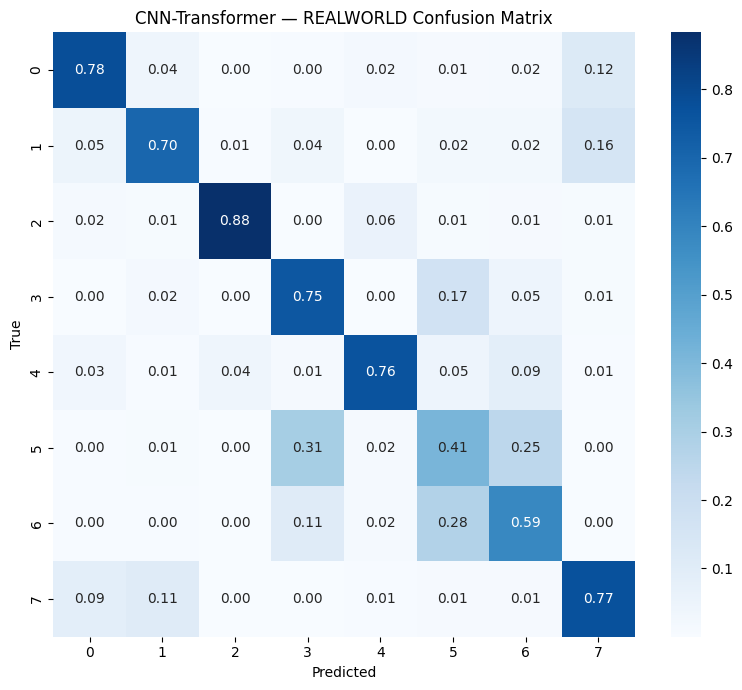

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
ٍ
print(f"CNN-Transformer — {DATASET} Classification Report")
print(classification_report(results["y_true"], results["y_pred"], digits=4))

cm = confusion_matrix(results["y_true"], results["y_pred"])
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 7))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"CNN-Transformer — {DATASET} Confusion Matrix")
plt.tight_layout()
plt.show()

## Save Results

Saves results under a name that includes the dataset, so results from
different datasets don't overwrite each other when this notebook is
re-run with a different `DATASET` value in Cell 4.

In [37]:
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/CNN_TRANSFORMER_RESULTS")
RESULTS_DIR.mkdir(exist_ok=True)

pd.to_pickle(results, RESULTS_DIR / f"cnn_transformer_{DATASET.lower()}_results.pkl")
print(f"Saved results for {DATASET} to: {RESULTS_DIR / f'cnn_transformer_{DATASET.lower()}_results.pkl'}")

Saved results for REALWORLD to: /lustre09/project/6081099/reem2005/DATASET/CNN_TRANSFORMER_RESULTS/cnn_transformer_realworld_results.pkl
